In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
train_data = datasets.ImageFolder(
    "../dataset/train",
    transform=transform
)
test_data= datasets.ImageFolder(
    "../dataset/test",
    transform=transform
)

print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Validation source images:", len(train_data))
print("Test images:", len(test_data))

Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Training images: 10109
Validation source images: 10109
Test images: 1279


In [5]:
targets = np.array(
    train_data.targets
)

indices = np.arange(
    len(train_data)
)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=targets    
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 8087
Validation samples: 2022


In [6]:
train_subset = Subset(
    train_data,
    train_indices
)

val_subset = Subset(
    train_data,
    val_indices
)

print(
    "Train subset:",
    len(train_subset)
)

print(
    "Validation subset:",
    len(val_subset)
)

Train subset: 8087
Validation subset: 2022


In [7]:
train_loader= DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

print("DataLoaders created.")

DataLoaders created.


In [8]:
from collections import Counter

train_labels = [
    train_data.targets[i]
    for i in train_indices
]

val_labels = [
    train_data.targets[i]
    for i in val_indices
]

print("TRAIN DISTRIBUTION")
print(Counter(train_labels))

print("\nVALIDATION DISTRIBUTION")
print(Counter(val_labels))

print("\nTEST DISTRIBUTION")
print(Counter(test_data.targets))

TRAIN DISTRIBUTION
Counter({0: 2047, 3: 2046, 1: 2011, 2: 1983})

VALIDATION DISTRIBUTION
Counter({0: 512, 3: 512, 1: 502, 2: 496})

TEST DISTRIBUTION
Counter({2: 640, 3: 448, 0: 179, 1: 12})


In [9]:

class AlzheimerResNet18(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        # Load ResNet-18 with pretrained ImageNet weights
        self.model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Get the number of input features to the final classifier
        in_features = self.model.fc.in_features

        # Replace the ImageNet classifier with a 4-class classifier
        self.model.fc = nn.Linear(
            in_features,
            num_classes
        )

    def forward(self, x):
        return self.model(x)


In [10]:
model = AlzheimerResNet18(num_classes=4).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\TANISHKA/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


AlzheimerResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [12]:
num_epochs = 10

for epoch in range(num_epochs):

    # ----- Training -----
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----- Validation -----
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.5590 Train Acc: 0.7609 Val Loss: 0.5534 Val Acc: 0.7710
Epoch [2/10] Train Loss: 0.3047 Train Acc: 0.8813 Val Loss: 0.4038 Val Acc: 0.8492
Epoch [3/10] Train Loss: 0.2061 Train Acc: 0.9220 Val Loss: 0.2543 Val Acc: 0.9159
Epoch [4/10] Train Loss: 0.1054 Train Acc: 0.9640 Val Loss: 0.1856 Val Acc: 0.9357
Epoch [5/10] Train Loss: 0.0889 Train Acc: 0.9680 Val Loss: 0.3200 Val Acc: 0.8912
Epoch [6/10] Train Loss: 0.0748 Train Acc: 0.9729 Val Loss: 0.1620 Val Acc: 0.9416
Epoch [7/10] Train Loss: 0.0514 Train Acc: 0.9808 Val Loss: 0.1067 Val Acc: 0.9649
Epoch [8/10] Train Loss: 0.0448 Train Acc: 0.9852 Val Loss: 0.1424 Val Acc: 0.9634
Epoch [9/10] Train Loss: 0.0474 Train Acc: 0.9833 Val Loss: 0.1867 Val Acc: 0.9446
Epoch [10/10] Train Loss: 0.0322 Train Acc: 0.9885 Val Loss: 0.1005 Val Acc: 0.9693


In [13]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

In [14]:
test_accuracy = accuracy_score(all_labels, all_predictions)
test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9390
Macro F1 Score: 0.9575


In [15]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_data.classes
))

                      precision    recall  f1-score   support

     Mild Impairment       0.99      0.94      0.97       179
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.96      0.93      0.95       640
Very Mild Impairment       0.89      0.95      0.92       448

            accuracy                           0.94      1279
           macro avg       0.96      0.96      0.96      1279
        weighted avg       0.94      0.94      0.94      1279



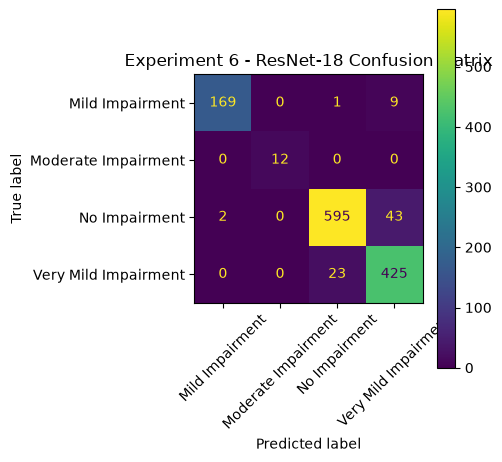

In [16]:
cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Experiment 6 - ResNet-18 Confusion Matrix")
plt.tight_layout()
plt.show()